# Task 2 — Exploratory Data Analysis and Initial Experimental Results

**Research question:** do CNBC geopolitical headlines add predictive value for the next-day direction of USD/IDR (Bank Indonesia JISDOR) beyond price history alone?

This notebook is the exploratory companion to the modular pipeline in `src/`. It does **not** re-implement any methodology. It reads:

| Input | Produced by |
|---|---|
| `data/processed/cnbc_headlines_aligned.csv`, `data/processed/cnbc_jisdor_daily.csv` | Task 1 pipeline |
| `data/interim/features/cnbc_headline_features.csv` | `python -m src.features.build_daily_features` |
| `data/splits/{train,validation,test}.csv` | `python -m src.modeling.export_splits` |
| `reports/*.json`, `reports/*.csv` | `python -m src.pipeline.run_task2` |

To refresh everything, run from the repository root:

```bash
python -m src.pipeline.run_task2
python -m src.modeling.export_splits
```

Full methodology: `docs/task2_plan.md`. Written results: `reports/task2_results.md`.

## 1. Setup

In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Locate the repository root so the notebook runs from repo root or notebook/."""
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "config/task2.yaml").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


ROOT = find_repo_root(Path.cwd())
os.chdir(ROOT)  # config/task2.yaml uses repo-relative paths
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features.build_daily_features import load_config

config = load_config(ROOT / "config/task2.yaml")
CATEGORIES = config["categories"]
MODEL_ORDER = ["B0", "B1", "B2", "M1", "M2", "M3", "M4"]

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 110
print("Repository root found:", ROOT.name)

Repository root found: NLP-Project_Event-Prediction-Analyzing-Impact-on-Dollar-Exchange-Rates


In [2]:
headlines = pd.read_csv("data/processed/cnbc_headlines_aligned.csv", parse_dates=["effective_trade_date"])
jisdor = pd.read_csv("data/processed/cnbc_jisdor_daily.csv", parse_dates=["date"])
articles = pd.read_csv("data/interim/features/cnbc_headline_features.csv", parse_dates=["effective_trade_date"])
splits = {
    name: pd.read_csv(f"data/splits/{name}.csv", parse_dates=["date"])
    for name in ["train", "validation", "test"]
}
results = json.loads(Path("reports/task2_results.json").read_text(encoding="utf-8"))

print(f"Aligned headlines:      {len(headlines):,}")
print(f"JISDOR trading days:    {len(jisdor):,}")
print(f"Article-level features: {len(articles):,}")
print("Split rows:", {name: len(frame) for name, frame in splits.items()})

Aligned headlines:      10,997
JISDOR trading days:    1,202
Article-level features: 10,997
Split rows: {'train': 825, 'validation': 176, 'test': 178}


## 2. Exploratory Data Analysis

### 2.1 Headline dataset

Each headline was assigned to a JISDOR trading day by Task 1 using its exact publisher timestamp in WIB (`Asia/Jakarta`) and a 15:00 WIB cutoff; weekend/holiday news moves forward to the next trading day.

In [3]:
overview = pd.Series({
    "headlines": len(headlines),
    "first effective trade date": headlines["effective_trade_date"].min().date(),
    "last effective trade date": headlines["effective_trade_date"].max().date(),
    "trading days with at least one headline": headlines["effective_trade_date"].nunique(),
    "JISDOR trading days in calendar": len(jisdor),
    "trading days with no headline": int((jisdor["news_count"] == 0).sum()),
})
display(overview.to_frame("value"))
display(headlines["alignment_reason"].value_counts().rename("headlines").to_frame())

,value
headlines,10997
first effective trade date,2021-09-01
last effective trade date,2026-09-01
trading days with at least one headline,1185
JISDOR trading days in calendar,1202
trading days with no headline,17


,headlines
alignment_reason,
after_cutoff_next_trade_day,4608
same_day_before_cutoff,4501
non_jisdor_day_next_trade_day,983
weekend_next_trade_day,905


### 2.2 USD/IDR (JISDOR) rate and daily returns

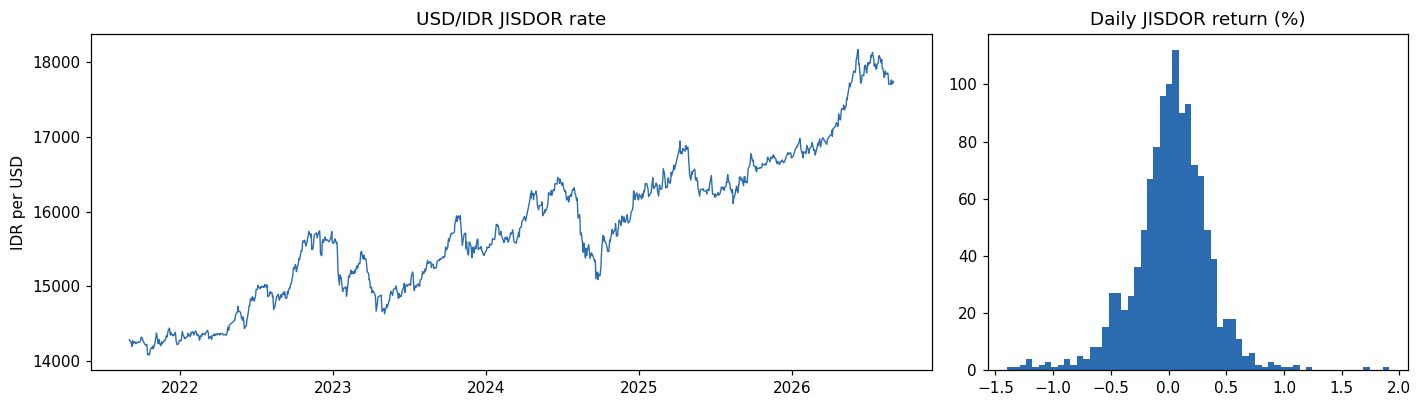

,return_pct
count,1201.0000
mean,0.0185
std,0.3334
min,-1.4013
25%,-0.1478
50%,0.0385
75%,0.2099
max,1.9089


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(jisdor["date"], jisdor["jisdor"], linewidth=0.9, color="#2b6cb0")
axes[0].set_title("USD/IDR JISDOR rate")
axes[0].set_ylabel("IDR per USD")
axes[1].hist(jisdor["return_pct"].dropna(), bins=60, color="#2b6cb0")
axes[1].set_title("Daily JISDOR return (%)")
plt.tight_layout()
plt.show()

display(jisdor["return_pct"].describe().to_frame("return_pct").round(4))

### 2.3 News volume and geopolitical categories

Categories are reused from Task 1 (`matched_categories`) and are **multi-label**: one headline can count toward several categories, so category totals exceed the headline total.

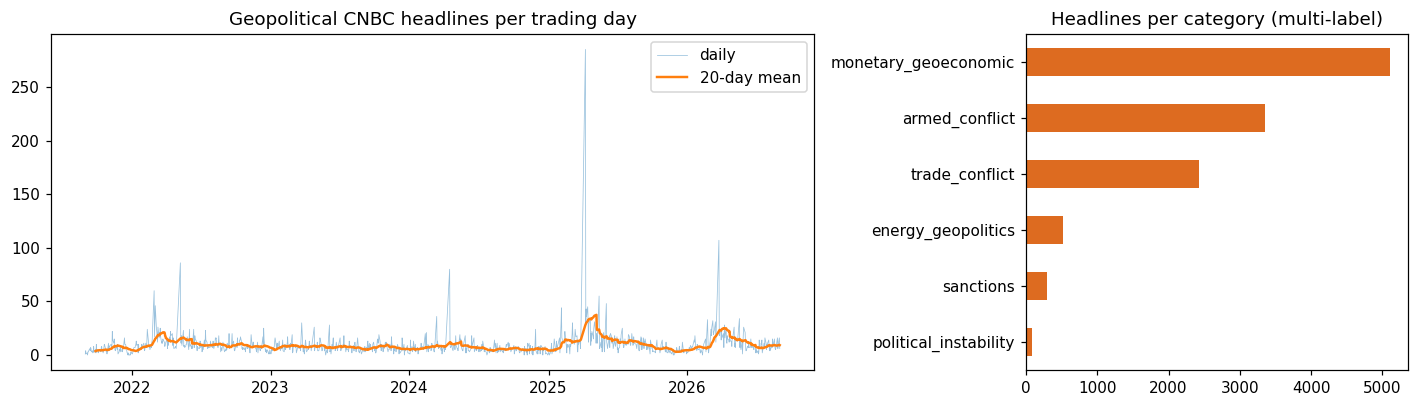

In [5]:
daily_news = jisdor.set_index("date")["news_count"]
category_totals = jisdor[[f"{c}_count" for c in CATEGORIES]].sum()
category_totals.index = [c.replace("_count", "") for c in category_totals.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [2, 1]})
axes[0].plot(daily_news.index, daily_news, linewidth=0.5, alpha=0.45, label="daily")
axes[0].plot(daily_news.index, daily_news.rolling(20).mean(), linewidth=1.6, label="20-day mean")
axes[0].set_title("Geopolitical CNBC headlines per trading day")
axes[0].legend()
category_totals.sort_values().plot.barh(ax=axes[1], color="#dd6b20")
axes[1].set_title("Headlines per category (multi-label)")
plt.tight_layout()
plt.show()

Category mix per split — a drifting mix means train and test see different kinds of news:

In [6]:
category_share = pd.DataFrame({
    name: frame[[f"{c}_count" for c in CATEGORIES]].sum() / frame["news_count"].sum()
    for name, frame in splits.items()
})
category_share.index = [c.replace("_count", "") for c in category_share.index]
display((category_share * 100).round(1).rename(columns=lambda c: f"{c} (% of headlines)"))

,train (% of headlines),validation (% of headlines),test (% of headlines)
armed_conflict,28.0,14.6,60.0
sanctions,3.6,1.0,1.6
trade_conflict,6.0,71.8,16.4
energy_geopolitics,5.7,1.6,5.4
political_instability,1.0,0.2,0.3
monetary_geoeconomic,60.7,22.3,26.1


### 2.4 Target: next-day direction

`y_t = 1` if the **next** trading day's JISDOR return is positive (USD strengthens / rupiah weakens), else 0. The target is next-day rather than same-day because news up to 15:00 WIB on day *t* is assigned to day *t*, which is after that day's JISDOR fixing; a same-day target would use news published after the rate it predicts.

In [7]:
balance = pd.DataFrame({
    name: {
        "rows": len(frame),
        "start": frame["date"].min().date(),
        "end": frame["date"].max().date(),
        "share next-day up": round(frame["y"].mean(), 3),
    }
    for name, frame in splits.items()
}).T
display(balance)
print("Zero-return days in the calendar (labelled 0, 'not up'):", int((jisdor["return_pct"] == 0).sum()))

,rows,start,end,share next-day up
train,825,2021-09-29,2025-02-24,0.558
validation,176,2025-02-26,2025-11-24,0.517
test,178,2025-11-26,2026-08-31,0.579


Zero-return days in the calendar (labelled 0, 'not up'): 13


### 2.5 Loughran-McDonald tone

Per headline: `lm_neg`, `lm_pos`, `lm_unc` = dictionary hits / tokens; `lm_net = (pos − neg) / (pos + neg + 1)`. A positive word preceded within 3 tokens by *no/not/never/none/without* counts as negative.

Headlines with at least one LM hit: 52.7%


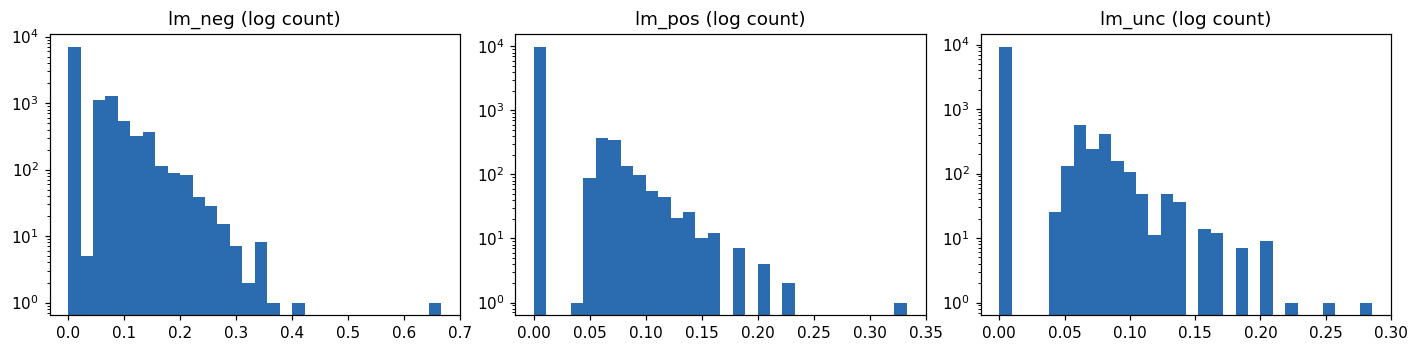

In [8]:
print(f"Headlines with at least one LM hit: {articles['lm_has_hit'].mean():.1%}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
for ax, column in zip(axes, ["lm_neg", "lm_pos", "lm_unc"]):
    ax.hist(articles[column], bins=30, color="#2b6cb0")
    ax.set_yscale("log")
    ax.set_title(f"{column} (log count)")
plt.tight_layout()
plt.show()

In [9]:
columns = ["effective_trade_date", "normalized_title", "lm_net"]
print("Most negative headlines:")
display(articles.nsmallest(5, "lm_net")[columns])
print("Most positive headlines:")
display(articles.nlargest(5, "lm_net")[columns])

Most negative headlines:


,effective_trade_date,normalized_title,lm_net
955,2022-03-07,"War fallout: U.S. economy to slow, Europe risk...",-0.833333
4847,2024-01-18,Fears of prolonged Red Sea shipping crisis fue...,-0.833333
10242,2026-04-30,Jet fuel bidding war breaks out as airlines co...,-0.833333
549,2022-01-18,China's Xi says countries must abandon 'Cold W...,-0.800000
3454,2023-03-20,International Criminal Court issues arrest war...,-0.800000


Most positive headlines:


,effective_trade_date,normalized_title,lm_net
1483,2022-05-09,"When inflation is high, Warren Buffett says th...",0.750000
2692,2022-10-31,Inflation bonds have surged in popularity amid...,0.750000
5999,2024-09-27,"Kamala Harris likely to win election, despite ...",0.750000
55,2021-09-23,"If the Fed sparks an interest rate rebound, hi...",0.666667
205,2021-11-04,Fund manager picks the global stocks set to ou...,0.666667


Overlap check: some taxonomy keywords are also LM Negative words, so tone and category are not fully independent.

In [10]:
overlap = pd.Series(
    {c: articles["lm_neg"].corr(articles[f"cat_{c}"]) for c in CATEGORIES},
    name="corr(lm_neg, category flag)",
).round(3)
display(overlap.to_frame())

,"corr(lm_neg, category flag)"
armed_conflict,0.100
sanctions,0.037
trade_conflict,0.008
energy_geopolitics,0.030
political_instability,0.088
monetary_geoeconomic,-0.107


### 2.6 TF-IDF topics (SVD components of the final M4 fit)

TF-IDF + SVD is fit on training-window headlines only. The components below come from the final train+validation refit of M4.

In [11]:
svd_terms = json.loads(Path("reports/svd_top_terms.json").read_text(encoding="utf-8"))["M4"]
print("SVD components selected for M4 on validation:", results["best_configs"]["M4"]["svd_k"])
topic_table = pd.DataFrame({
    component: {
        "top positive terms": ", ".join(info["top_positive_terms"][:8]),
        "explained variance": round(info["explained_variance_ratio"], 4),
    }
    for component, info in list(svd_terms.items())[:8]
}).T
display(topic_table)

SVD components selected for M4 on validation: 20


,top positive terms,explained variance
svd_0,"inflation, fed, says, trump, tariffs, rate, tr...",0.0024
svd_1,"trump, war, ukraine, tariffs, russia, says, tr...",0.0089
svd_2,"tariffs, trump, trump tariffs, tariff, stocks,...",0.0079
svd_3,"treasury, yield, year treasury, treasury yield...",0.0071
svd_4,"fed, rate, federal, federal reserve, reserve, ...",0.0064
svd_5,"inflation, says, year, cramer, 10, prices, jim...",0.0053
svd_6,"yields, treasury yields, treasury, investors, ...",0.0052
svd_7,"federal, reserve, federal reserve, inflation, ...",0.0048


## 3. Initial Experimental Results

| ID | Model | Features |
|---|---|---|
| B0 | Majority class | — |
| B1 | Persistence | tomorrow = today's direction |
| B2 | Logistic regression | price only |
| M1 | Logistic regression | price + news counts |
| M2 | Logistic regression | price + LM tone |
| M3 | Logistic regression | price + TF-IDF/SVD |
| M4 | Logistic regression | price + counts + LM + TF-IDF/SVD |

All logistic models share the same grid (C, penalty, class weight, plus SVD k for M3/M4), are tuned on validation accuracy (macro-F1 tie-break), refit on train+validation, and scored once on test.

### 3.1 Validation-selected configurations

In [12]:
tuning = pd.read_csv("reports/task2_tuning_log.csv")
best = pd.DataFrame(results["best_configs"]).T
display(best[["svd_k", "C", "penalty", "class_weight", "val_accuracy", "val_macro_f1"]])
print("Grid configurations tried in total:", len(tuning))

,svd_k,C,penalty,class_weight,val_accuracy,val_macro_f1
B2,None,1,l1,None,0.573864,0.538058
M1,None,1,l1,balanced,0.534091,0.530208
M2,None,0.01,l2,balanced,0.534091,0.534091
M3,20,0.01,l2,None,0.551136,0.543338
M4,20,0.1,l2,None,0.556818,0.553996


Grid configurations tried in total: 144


### 3.2 Test-set performance (178 trading days)

,accuracy,macro_f1,mcc,accuracy 95% CI low,accuracy 95% CI high
model,,,,,
B0,0.579,0.367,0.000,0.511,0.652
B1,0.545,0.533,0.065,0.489,0.618
B2,0.545,0.470,-0.005,0.472,0.624
M1,0.511,0.500,-0.001,0.444,0.584
M2,0.472,0.471,-0.043,0.404,0.551
M3,0.522,0.476,-0.027,0.444,0.601
M4,0.500,0.488,-0.024,0.433,0.568


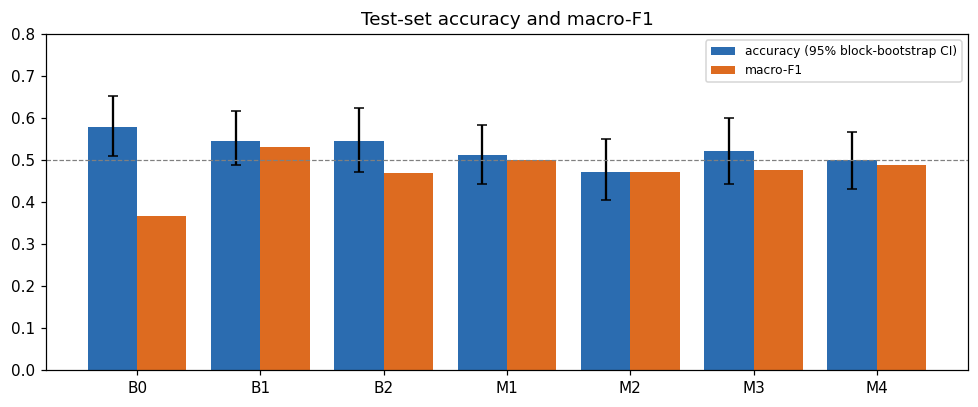

In [13]:
rows = []
for model_id in MODEL_ORDER:
    metrics = results["test_metrics"][model_id]
    rows.append({
        "model": model_id,
        "accuracy": metrics["accuracy"],
        "macro_f1": metrics["macro_f1"],
        "mcc": metrics["mcc"],
        "accuracy 95% CI low": metrics["bootstrap"]["accuracy_ci"][0],
        "accuracy 95% CI high": metrics["bootstrap"]["accuracy_ci"][1],
    })
test_table = pd.DataFrame(rows).set_index("model")
display(test_table.round(3))

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(test_table))
lower = test_table["accuracy"] - test_table["accuracy 95% CI low"]
upper = test_table["accuracy 95% CI high"] - test_table["accuracy"]
ax.bar(x - 0.2, test_table["accuracy"], 0.4, yerr=[lower, upper], capsize=3, label="accuracy (95% block-bootstrap CI)", color="#2b6cb0")
ax.bar(x + 0.2, test_table["macro_f1"], 0.4, label="macro-F1", color="#dd6b20")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(test_table.index)
ax.set_ylim(0, 0.8)
ax.set_title("Test-set accuracy and macro-F1")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.3 Does news add value? (pre-registered decision rule)

In [14]:
decision = results["decision"]
m4_vs_b2 = pd.Series({
    "M4 beats B2 on accuracy": decision["m4_beats_b2_accuracy"],
    "M4 beats B2 on macro-F1": decision["m4_beats_b2_macro_f1"],
    "McNemar p-value (M4 vs B2)": round(decision["mcnemar_m4_vs_b2_p_value"], 3),
    "news adds predictive value": decision["news_adds_predictive_value"],
})
display(m4_vs_b2.to_frame("value"))
print(decision["verdict"])

,value
M4 beats B2 on accuracy,False
M4 beats B2 on macro-F1,True
McNemar p-value (M4 vs B2),0.358
news adds predictive value,False


No evidence of added value at this sample size (see docs/task2_plan.md section 3.5).


### 3.4 Walk-forward robustness check

Expanding window with monthly refits (hyperparameters fixed to the tuned values). This covers far more out-of-sample days than the single test window and is not used for model selection.

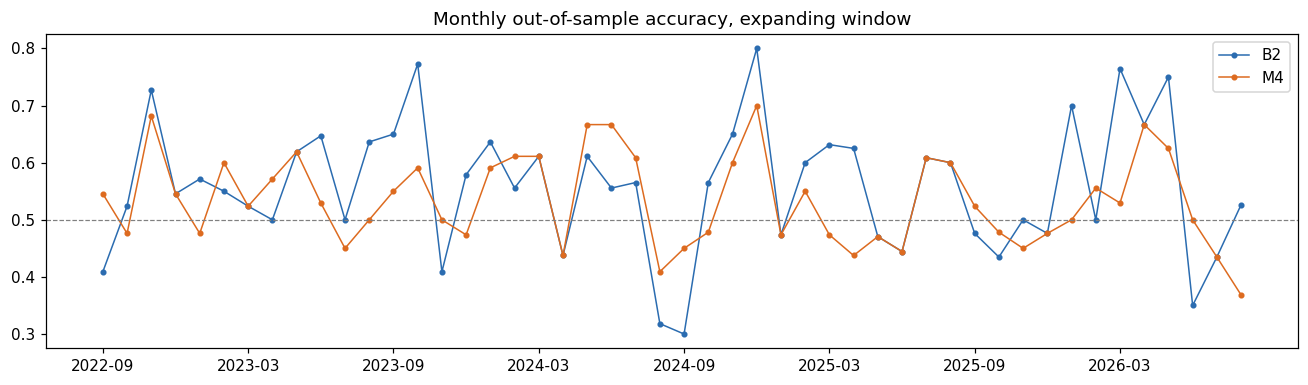

,mean,std,count
model_id,,,
B2,0.558,0.115,48.0
M4,0.534,0.080,48.0


In [15]:
walk_forward = pd.read_csv("reports/task2_walk_forward.csv")
monthly = walk_forward.pivot(index="month", columns="model_id", values="accuracy")

fig, ax = plt.subplots(figsize=(12, 3.6))
for model_id, color in [("B2", "#2b6cb0"), ("M4", "#dd6b20")]:
    ax.plot(monthly.index, monthly[model_id], marker="o", markersize=3, linewidth=1, label=model_id, color=color)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("Monthly out-of-sample accuracy, expanding window")
ax.set_xticks(monthly.index[::6])
ax.legend()
plt.tight_layout()
plt.show()

display(monthly.agg(["mean", "std", "count"]).T.round(3))

## 4. Takeaways

- **No evidence that CNBC headline features improve next-day USD/IDR direction prediction** at this sample size: M4 does not beat the price-only B2 on accuracy, and McNemar is far from significant. The walk-forward check points the same way.
- The test period is unusually one-sided (≈58% up-days), which is why the majority-class B0 has the highest raw accuracy despite a macro-F1 near 0.37 — accuracy is never read alone.
- The news mix shifts sharply between splits (section 2.3): trade-conflict headlines are ~6% of training headlines but ~72% of validation (the 2025 tariff period), and armed conflict is ~60% of test. A model fit on 2021–2025 news is evaluated on a different news regime.
- Likely reasons, not pipeline defects: headlines are short (8–15 tokens, ~53% LM coverage), the LM dictionary was built for 10-K filings, CNBC is US-centric with thin coverage of Indonesia-specific drivers, and 56 features in the final M4 against 825 training days invites overfitting.
- Categories are keyword-retrieval labels from Task 1, not verified relevance labels.